In [2]:
%load_ext autoreload
%autoreload 2

In [7]:
import numpy as np
from wrf_io import postproc
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_squared_error

In [8]:
base_path = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'

In [9]:
orig_kernel, opt_kernel_rot = postproc.build_kernel_from_search(base_path + '/results/rotor/wrf_10MW_rot_D3_result.txt')

Kernel line:
ScoredKernel(k_opt=SumKernel([ MaskKernel(ndim=3, active_dimension=1, base_kernel=SqExpKernel(lengthscale=-0.366678, output_variance=1.364362)), ProductKernel([ MaskKernel(ndim=3, active_dimension=0, base_kernel=SqExpKernel(lengthscale=2.555432, output_variance=4.381824)), MaskKernel(ndim=3, active_dimension=2, base_kernel=SqExpKernel(lengthscale=2.341696, output_variance=-2.022604)) ]) ]), nll=-107.193919, laplace_nle=nan, bic_nle=-193.672165, noise=[-4.23481442])

Noise:
-4.23481442

Kernel specification string:
SumKernel([ MaskKernel(ndim=3, active_dimension=1, base_kernel=SqExpKernel(lengthscale=-0.366678, output_variance=1.364362)), ProductKernel([ MaskKernel(ndim=3, active_dimension=0, base_kernel=SqExpKernel(lengthscale=2.555432, output_variance=4.381824)), MaskKernel(ndim=3, active_dimension=2, base_kernel=SqExpKernel(lengthscale=2.341696, output_variance=-2.022604)) ]) ])

Kernel structure:
{'children': [{'active_dimension': 1,
               'base_kernel': {'leng

In [10]:
postproc.compare_kernel_dict_and_sklearn(orig_kernel, opt_kernel_rot, tol=0.1, verbose=True)

root: kernel_dict children: [{'type': 'mask', 'ndim': 3, 'active_dimension': 1, 'base_kernel': {'type': 'sqexp', 'lengthscale': -0.366678, 'variance': 1.364362}}, {'type': 'product', 'children': [{'type': 'mask', 'ndim': 3, 'active_dimension': 0, 'base_kernel': {'type': 'sqexp', 'lengthscale': 2.555432, 'variance': 4.381824}}, {'type': 'mask', 'ndim': 3, 'active_dimension': 2, 'base_kernel': {'type': 'sqexp', 'lengthscale': 2.341696, 'variance': -2.022604}}]}]
root: sk_children: [MaskedKernel(1.98**2 * RBF(length_scale=0.693), active_dims=[1]), MaskedKernel(8.94**2 * RBF(length_scale=12.9), active_dims=[0]) * MaskedKernel(0.364**2 * RBF(length_scale=10.4), active_dims=[2])]
root.sum[1]: kernel_dict children: [{'type': 'mask', 'ndim': 3, 'active_dimension': 0, 'base_kernel': {'type': 'sqexp', 'lengthscale': 2.555432, 'variance': 4.381824}}, {'type': 'mask', 'ndim': 3, 'active_dimension': 2, 'base_kernel': {'type': 'sqexp', 'lengthscale': 2.341696, 'variance': -2.022604}}]
root.sum[1]: s

True

In [22]:
# Load training data
X_train_rot = loadmat(base_path + '/train_data/wrf_10MW_rot.mat')

X_rot = X_train_rot['X']
y_rot = X_train_rot['y'].ravel()

In [23]:
# Train the GP model
gpr = GaussianProcessRegressor(kernel=opt_kernel_rot, optimizer=None, normalize_y=False)
# gpr = GaussianProcessRegressor(kernel=opt_kernel_rot, optimizer='fmin', normalize_y=False)
gpr.fit(X_rot, y_rot)

GaussianProcessRegressor(kernel=MaskedKernel(1.98**2 * RBF(length_scale=0.693), active_dims=[1]) + MaskedKernel(8.94**2 * RBF(length_scale=12.9), active_dims=[0]) * MaskedKernel(0.364**2 * RBF(length_scale=10.4), active_dims=[2]) + WhiteKernel(noise_level=0.0145),
                         optimizer=None)

In [24]:
# Load test data
X_test_rot = loadmat(base_path + '/test_data/wrf_10MW_rot.mat')
import pickle

X_t_rot = np.zeros((250,3))

# Replace with the actual file path
with open(base_path + '/train_data/scaler_wrf_cot_rot.pkl', 'rb') as f:
    obj_cot1 = pickle.load(f)

with open(base_path + '/train_data/scaler_shears_rot.pkl', 'rb') as f:
    obj_cot2 = pickle.load(f)

with open(base_path + '/train_data/scaler_veers_rot.pkl', 'rb') as f:
    obj_cot3 = pickle.load(f)

with open(base_path + '/train_data/scaler_wrf_ind_rot.pkl', 'rb') as f:
    obj_ann = pickle.load(f)

# X_t_rot = np.zeros((90,3))
# X_t_rot[:,0] = obj_cot1.inverse_transform(X_test_rot['X'][:,0].reshape(-1, 1)).ravel()
# X_t_rot[:,1] = obj_cot2.inverse_transform(X_test_rot['X'][:,1].reshape(-1, 1)).ravel()
# X_t_rot[:,2] = obj_cot3.inverse_transform(X_test_rot['X'][:,2].reshape(-1, 1)).ravel()
# y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])
# X_t_rot = X_test_rot['X']
y_t_rot = X_test_rot['y']

In [25]:
X_t_rot[:,0] = obj_cot1.transform(np.linspace(0.66,0.72,250).reshape(-1, 1)).ravel()
X_t_rot[:,1] = obj_cot2.transform(0.03*np.ones(250).reshape(-1, 1)).ravel()
X_t_rot[:,2] = obj_cot3.transform(0.2*np.ones(250).reshape(-1, 1)).ravel()
X_t_rot

array([[-3.97330828,  1.5       ,  1.84071597],
       [-3.93820588,  1.5       ,  1.84071597],
       [-3.90310349,  1.5       ,  1.84071597],
       [-3.86800109,  1.5       ,  1.84071597],
       [-3.83289869,  1.5       ,  1.84071597],
       [-3.79779629,  1.5       ,  1.84071597],
       [-3.76269389,  1.5       ,  1.84071597],
       [-3.7275915 ,  1.5       ,  1.84071597],
       [-3.6924891 ,  1.5       ,  1.84071597],
       [-3.6573867 ,  1.5       ,  1.84071597],
       [-3.6222843 ,  1.5       ,  1.84071597],
       [-3.5871819 ,  1.5       ,  1.84071597],
       [-3.55207951,  1.5       ,  1.84071597],
       [-3.51697711,  1.5       ,  1.84071597],
       [-3.48187471,  1.5       ,  1.84071597],
       [-3.44677231,  1.5       ,  1.84071597],
       [-3.41166991,  1.5       ,  1.84071597],
       [-3.37656752,  1.5       ,  1.84071597],
       [-3.34146512,  1.5       ,  1.84071597],
       [-3.30636272,  1.5       ,  1.84071597],
       [-3.27126032,  1.5       ,  1.840

In [26]:
A_pred, sigma = gpr.predict(X_t_rot, return_std=True)

X_t_rot = np.zeros((90,3))
X_t_rot[:,0] = obj_cot1.inverse_transform(X_test_rot['X'][:,0].reshape(-1, 1)).ravel()
X_t_rot[:,1] = obj_cot2.inverse_transform(X_test_rot['X'][:,1].reshape(-1, 1)).ravel()
X_t_rot[:,2] = obj_cot3.inverse_transform(X_test_rot['X'][:,2].reshape(-1, 1)).ravel()
y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])

# X_t_rot = obj_cot.inverse_transform(X_test_rot['X'])
# y_t_rot = obj_ann.inverse_transform(X_test_rot['y'])
A_pred = obj_ann.inverse_transform(A_pred.reshape(-1, 1))

In [25]:
A_pred

array([[0.28202768],
       [0.28174597],
       [0.28146336],
       [0.28117986],
       [0.28089547],
       [0.2806102 ],
       [0.28032406],
       [0.28003704],
       [0.27974917],
       [0.27946043],
       [0.27917084],
       [0.2788804 ],
       [0.27858912],
       [0.278297  ],
       [0.27800405],
       [0.27771027],
       [0.27741568],
       [0.27712027],
       [0.27682405],
       [0.27652703],
       [0.27622921],
       [0.2759306 ],
       [0.2756312 ],
       [0.27533103],
       [0.27503008],
       [0.27472836],
       [0.27442588],
       [0.27412265],
       [0.27381866],
       [0.27351394],
       [0.27320847],
       [0.27290227],
       [0.27259535],
       [0.27228771],
       [0.27197935],
       [0.27167029],
       [0.27136053],
       [0.27105007],
       [0.27073893],
       [0.2704271 ],
       [0.2701146 ],
       [0.26980143],
       [0.26948759],
       [0.2691731 ],
       [0.26885796],
       [0.26854217],
       [0.26822575],
       [0.267

ValueError: Found input variables with inconsistent numbers of samples: [90, 250]

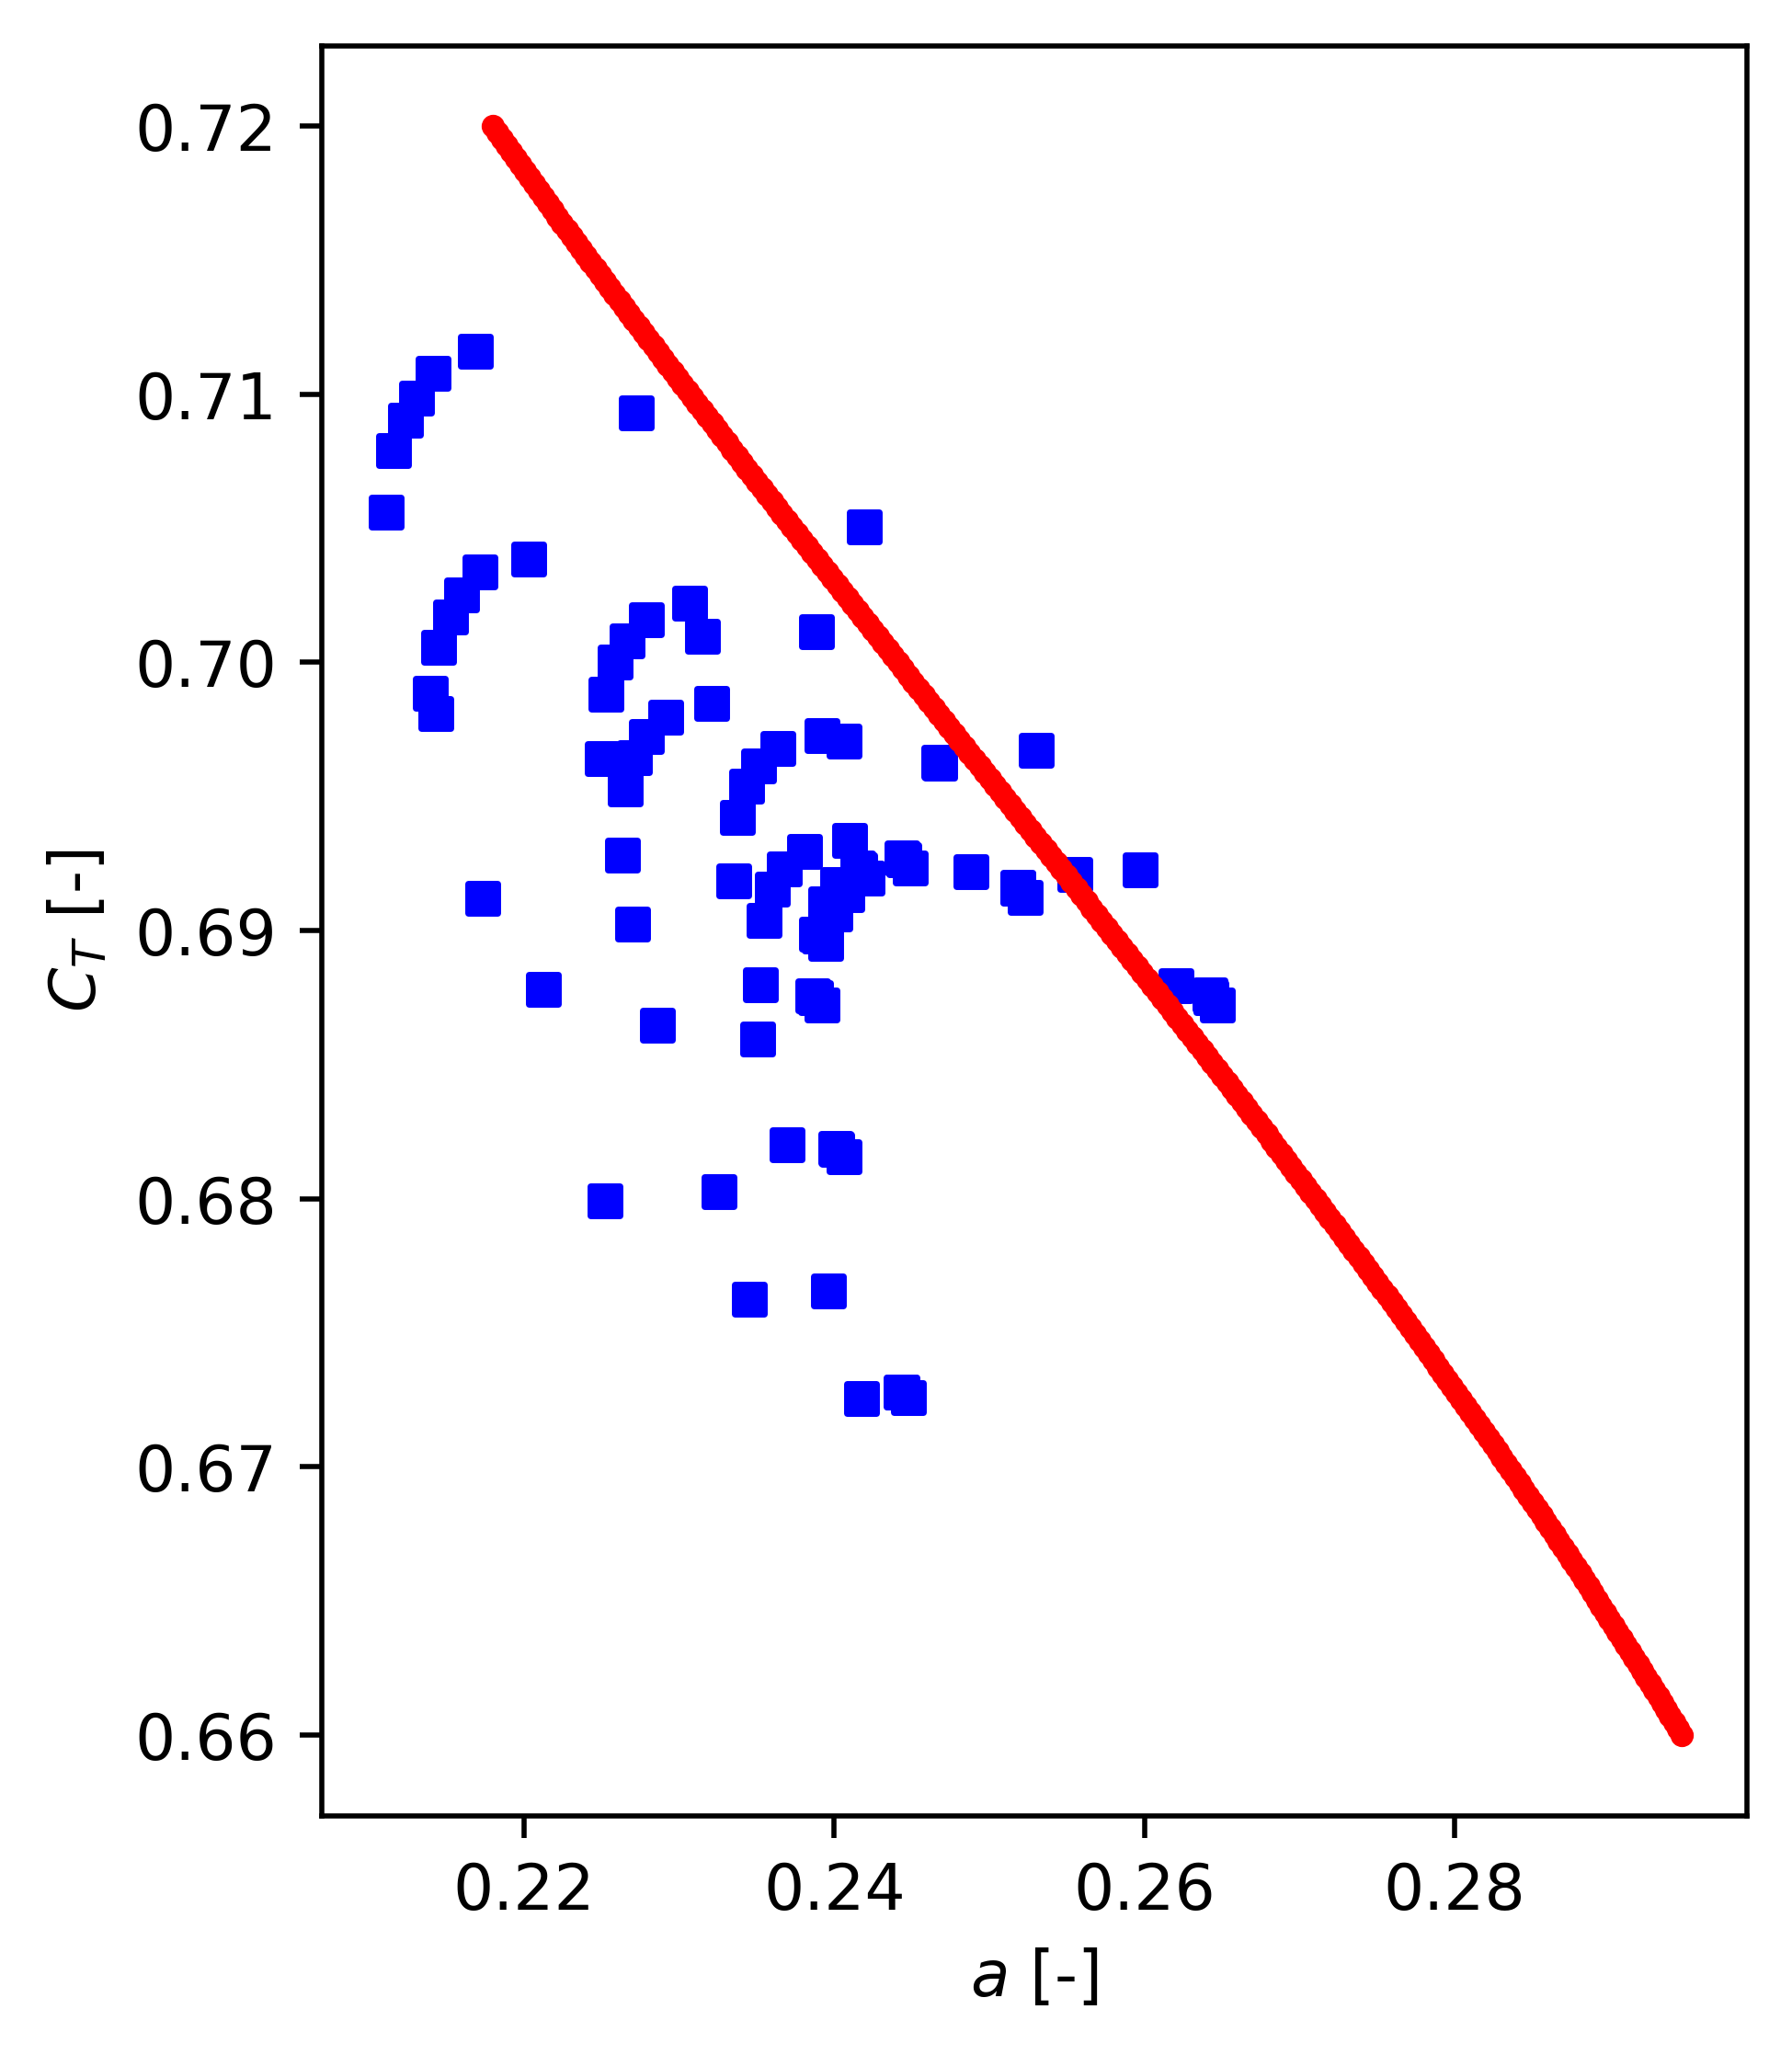

In [27]:
out_sample = np.array([0,1,2,3,4,5,6,7,8,9,10,19,20,29,30,39,40,49,50,69,70,79,80,81,82,83,84,85,86,87,88,89])
full_range = np.arange(0, 90)  # inclusive of 90
in_sample = np.setdiff1d(full_range, out_sample)

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(4, 5))

# ax.plot(a_mom,ct_mom,'#ff3c00',zorder=1)
# ax.plot(a_mad,ct_mad,'k--',zorder=1)
# ax.scatter(y_train,X_train[:,0],color='b')

ax.scatter(y_t_rot, X_t_rot[:, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')

# ax.scatter(y_t_rot[out_sample], X_t_rot[out_sample, 0], s=20, color='b', marker='s', label='Test data (out-of-sample)')
# ax.scatter(y_t_rot[in_sample], X_t_rot[in_sample, 0], s=20, color='b', marker='o', label='Test data (in-sample)')

ax.scatter(A_pred,np.linspace(0.66,0.72,250),7,color='r', label = 'GP Prediction')

# ax.set_xlim([0.21,0.28])
# ax.set_ylim([0.65,0.725])

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')

rmse = np.sqrt(mean_squared_error(y_t_rot, A_pred))
ax.legend(fontsize=7, title=f"RMSE: {rmse:.2e}")

In [35]:
rmse

np.float64(0.001606680491155459)

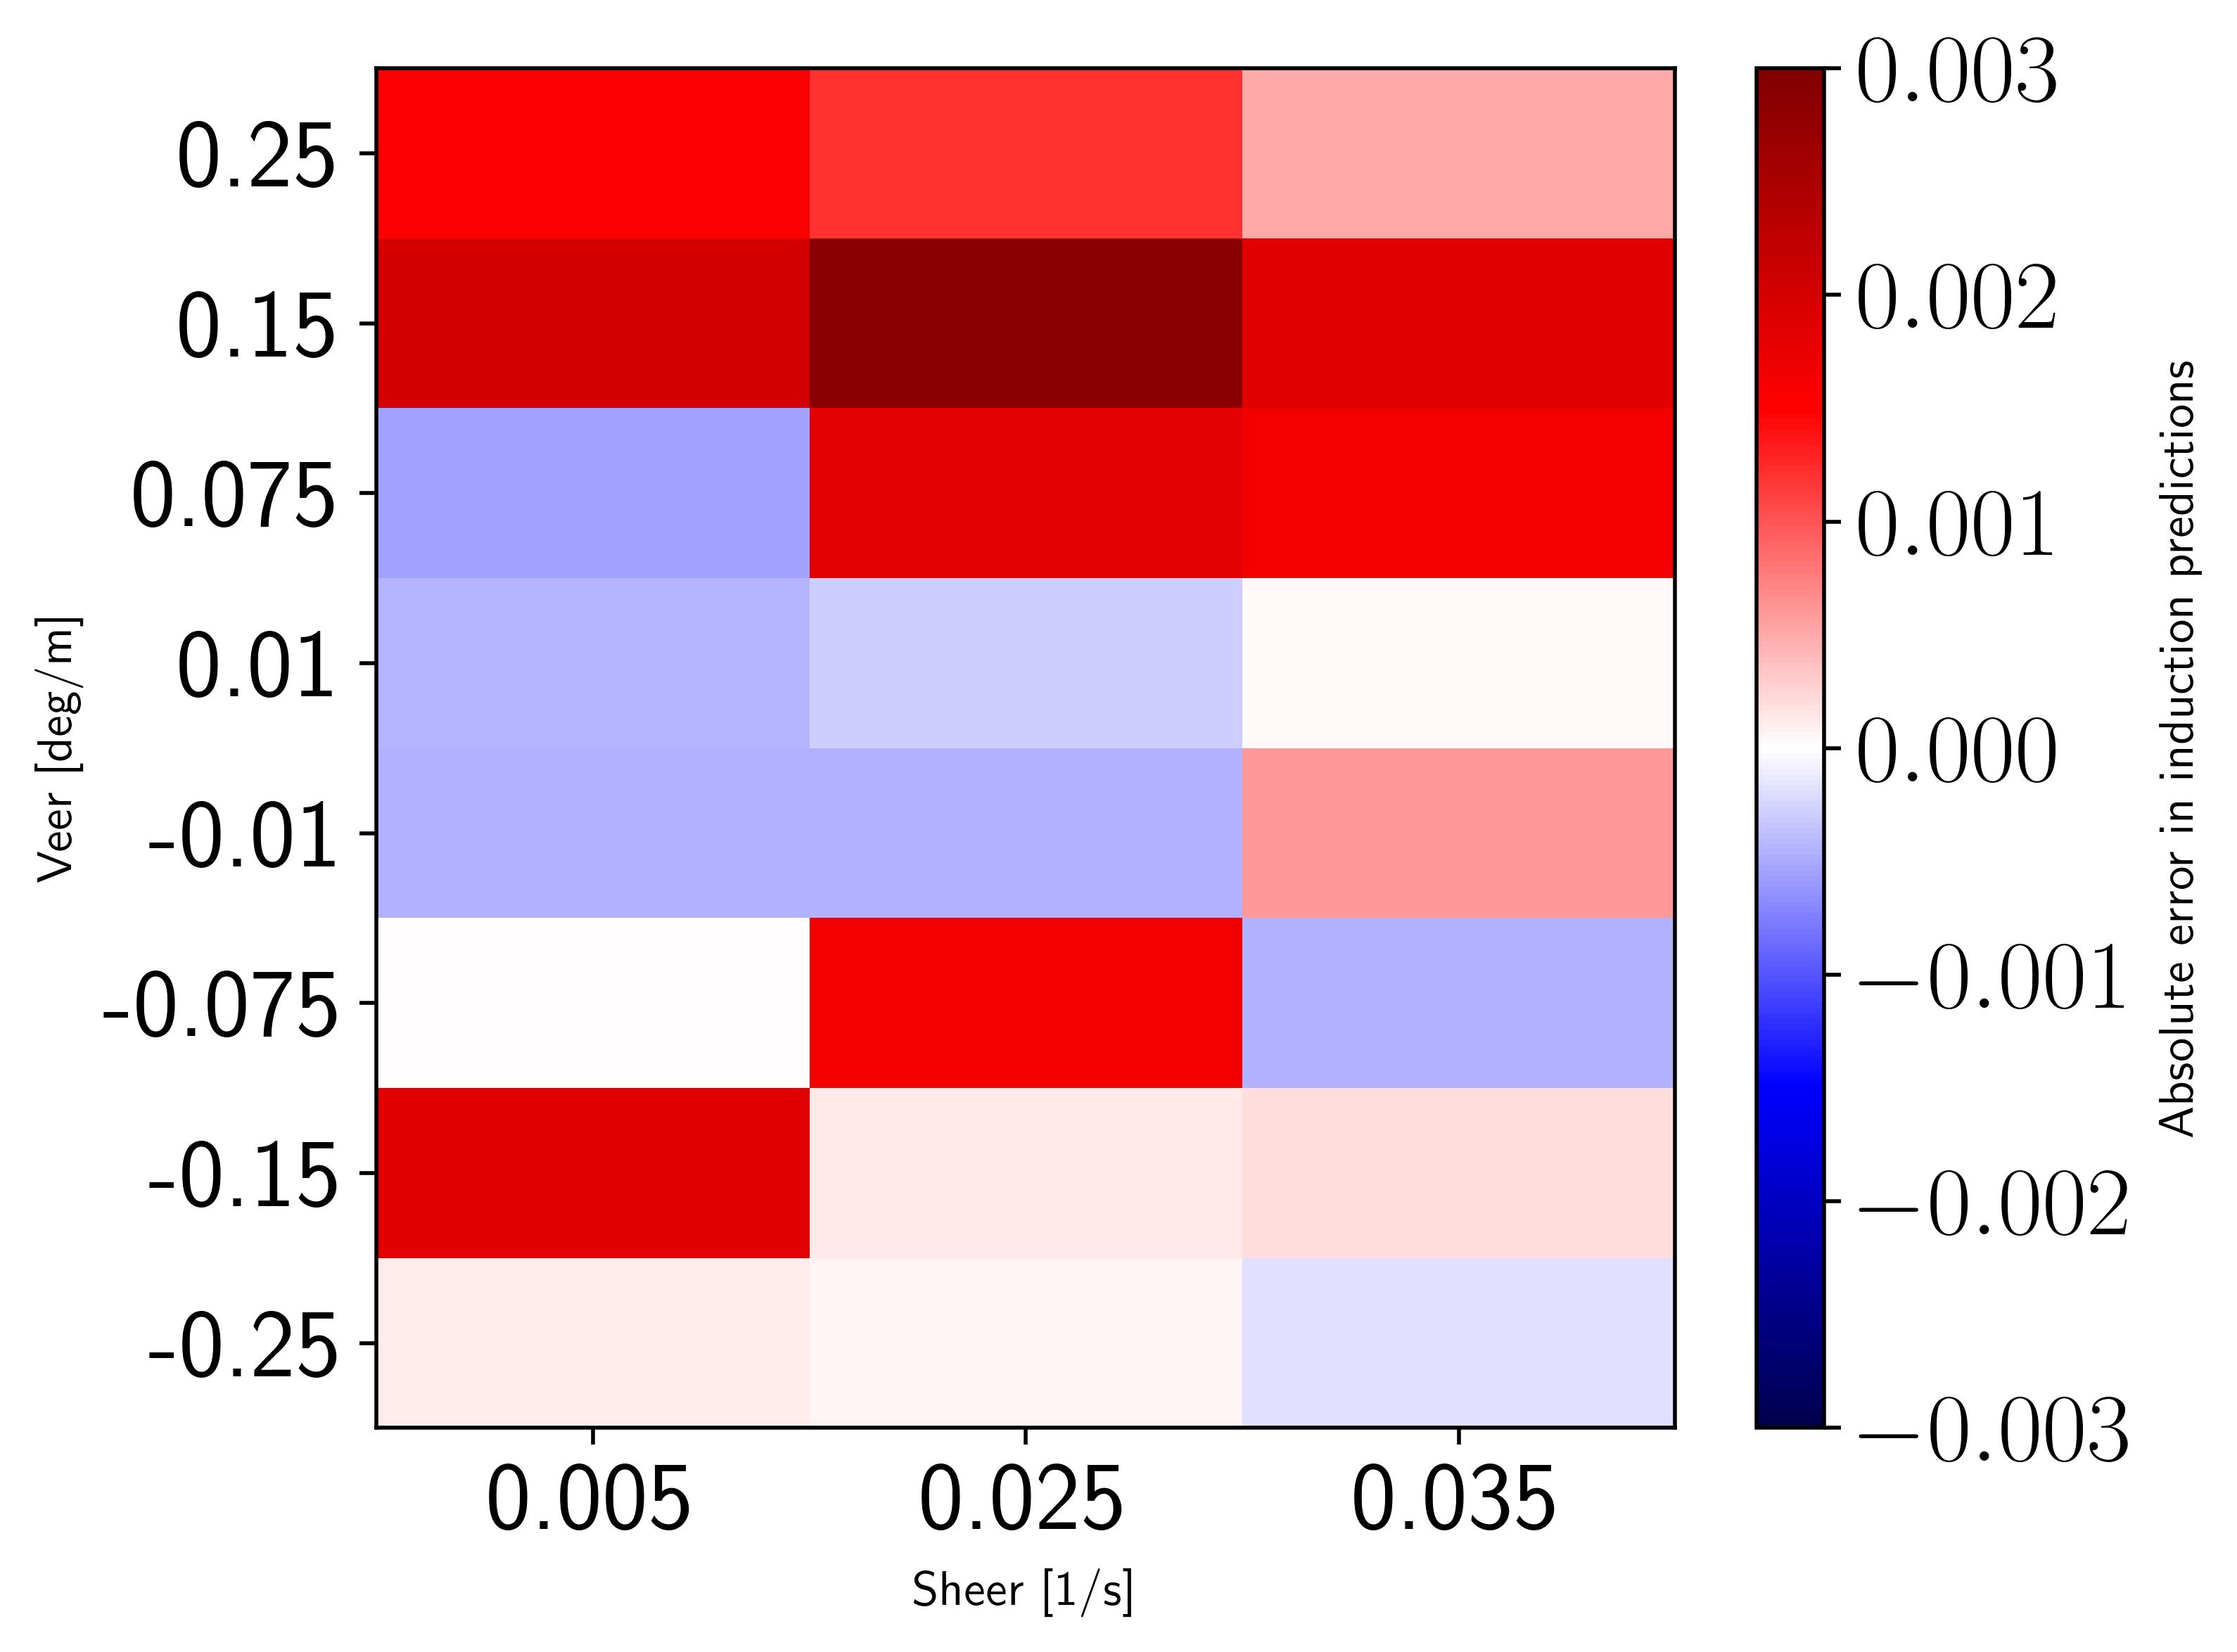

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D data
data = (y_test - A_pred).reshape(8,3)
# data = A_pred.reshape(8,3)


# Define the edges of the grid (must be one more than data.shape)
x_edges = np.arange(data.shape[1] + 1)  # 4 edges for 3 columns
y_edges = np.arange(data.shape[0] + 1)  # 5 edges for 4 rows

r's035_v010',
r's035_v075',
r's035_v150',
r's035_v250',
r's035_vn010',
r's035_vn075',
r's035_vn150',
r's035_vn250',

# Define tick labels you want to appear at cell centers
x_tick_labels = ['0.005', '0.025', '0.035']
y_tick_labels = ['-0.25','-0.15','-0.075','-0.01','0.01','0.075','0.15','0.25']

# Compute centers of the grid cells (midpoints between edges)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Set custom tick locations (centers of cells)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

# Plot
fig, ax = plt.subplots()
mesh = ax.pcolormesh(x_edges, y_edges, data, shading='auto', cmap='seismic',vmin=-0.003,vmax=0.003)

# Set ticks at cell centers
ax.set_xticks(x_centers)
ax.set_xticklabels(x_tick_labels)

ax.set_yticks(y_centers)
ax.set_yticklabels(y_tick_labels)

# Optional: add a colorbar
plt.colorbar(mesh, ax=ax, label='Absolute error in induction predictions')
plt.ylabel('Veer [deg/m]')
plt.xlabel('Sheer [1/s]')
plt.tight_layout()
plt.show()

In [167]:
data

array([[ 1.15015338e-04,  6.17230698e-05, -1.84967757e-04],
       [ 1.85704842e-03,  1.30309843e-04,  2.09168802e-04],
       [ 1.77425064e-05,  1.64617297e-03, -4.59429252e-04],
       [-4.67581334e-04, -4.47170470e-04,  5.99205096e-04],
       [-4.36760437e-04, -3.03059934e-04,  4.23056248e-05],
       [-5.56503308e-04,  1.82728353e-03,  1.64561741e-03],
       [ 2.01242809e-03,  2.86916226e-03,  1.85984577e-03],
       [ 1.55106164e-03,  1.20155882e-03,  5.00825900e-04]])

In [92]:
A_pred

array([0.25194899, 0.24890544, 0.24874281, 0.24912277, 0.2498527 ,
       0.25097282, 0.25247105, 0.25648237, 0.26755682])